## PHASE 4: BIVARIANT ANALYSIS



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r'D:\chennai1-pg-price-predictor\Data\processed\EDA\01_eda_Phase-2_processed.csv')

In [4]:
df = df.drop(columns=['lunch','dinner','breakfast'])

In [5]:
def scatter_analysis(df, x, y):
    plt.figure(figsize=(8,5))
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y
    )
    
    plt.title(f"{x} vs {y}")
    plt.show()
    
    corr = df[[x,y]].corr().iloc[0,1]
    
    print(f"Pearson Correlation : {corr:.3f}")
    
def box_analysis(df,cat,target):
    plt.figure(figsize=(8,5))
    
    sns.boxplot(
        data=df,
        x=cat,
        y=target
    )
    
    plt.xticks(rotation=45)
    
    plt.title(f"{target} by {cat}")
    
    plt.show()
    
    display(
        df.groupby(cat)[target]
        .agg(['count','mean','median'])
        .sort_values('mean',ascending=False)
    )
    
def crosstab_analysis(df,col1,col2):
    table = pd.crosstab(
        df[col1],
        df[col2],
        normalize="index"
    )
    
    display(table)
    
    plt.figure(figsize=(8,5))
    
    sns.heatmap(
        table,
        annot=True,
        cmap="Blues",
        fmt=".2f"
    )
    
    plt.title(f"{col1} vs {col2}")
    
    plt.show()

# 4.1 Numerical vs Numerical

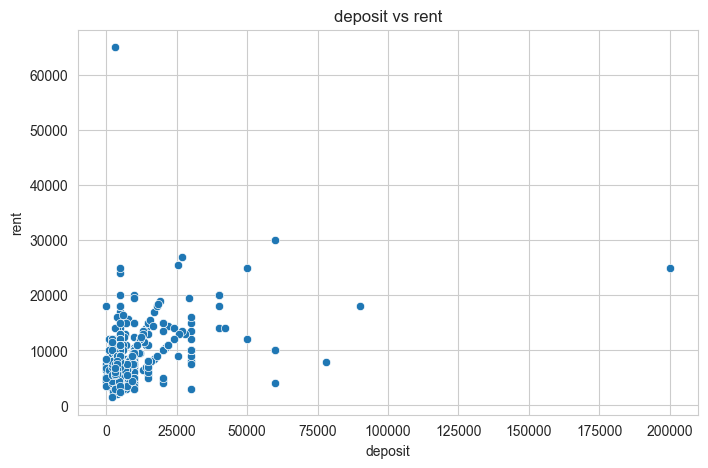

Pearson Correlation : 0.402


In [6]:
scatter_analysis(df, x='deposit', y='rent')

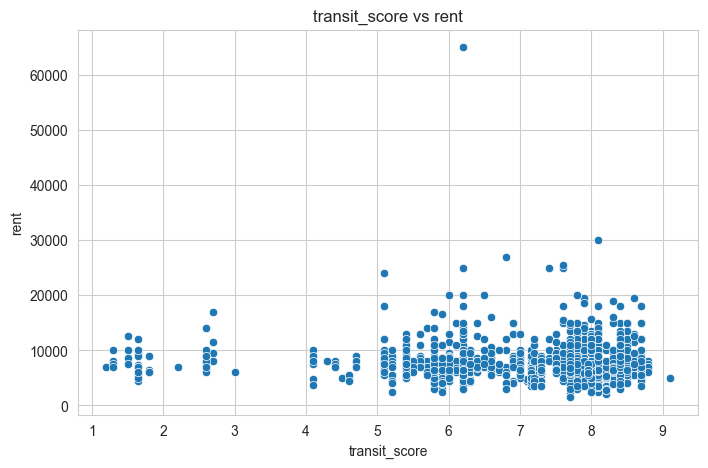

Pearson Correlation : -0.037


In [7]:
scatter_analysis(df, x='transit_score' , y='rent')

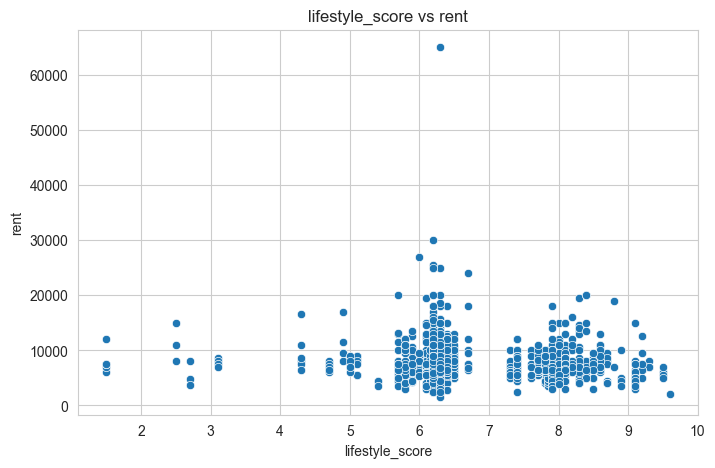

Pearson Correlation : -0.060


In [8]:
scatter_analysis(df, x='lifestyle_score' , y='rent')

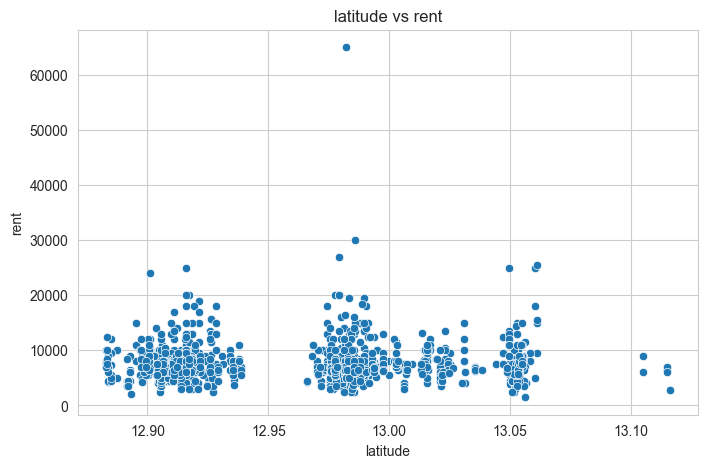

Pearson Correlation : 0.030


In [9]:
scatter_analysis(df, x='latitude', y='rent')

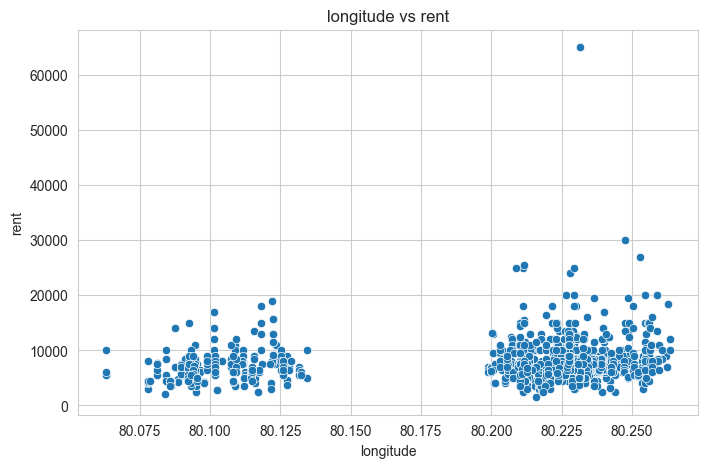

Pearson Correlation : 0.110


In [10]:
scatter_analysis(df, x='longitude', y='rent')

# 4.2 correlation matrix(nummeric columns)

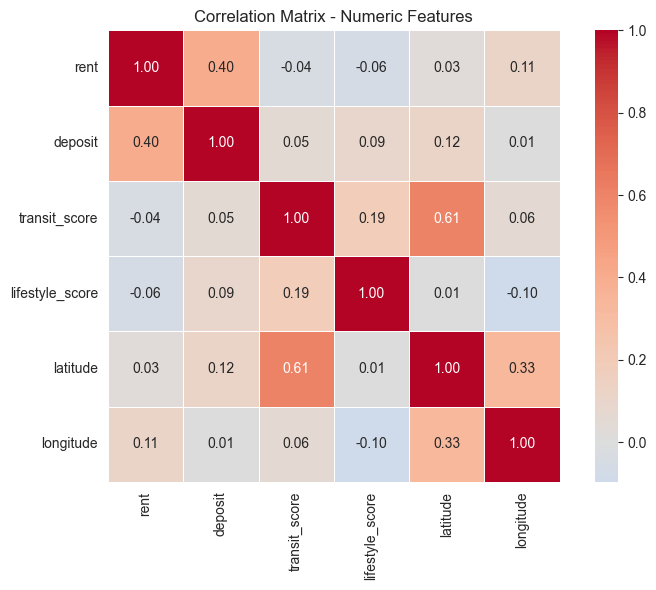

                     rent   deposit  transit_score  lifestyle_score  latitude  \
rent             1.000000  0.402189      -0.037343        -0.060421  0.030479   
deposit          0.402189  1.000000       0.050005         0.089745  0.116715   
transit_score   -0.037343  0.050005       1.000000         0.187059  0.608890   
lifestyle_score -0.060421  0.089745       0.187059         1.000000  0.007170   
latitude         0.030479  0.116715       0.608890         0.007170  1.000000   
longitude        0.110142  0.010020       0.058931        -0.096782  0.331611   

                 longitude  
rent              0.110142  
deposit           0.010020  
transit_score     0.058931  
lifestyle_score  -0.096782  
latitude          0.331611  
longitude         1.000000  


In [11]:
# 4.1 Correlation Heatmap (numeric columns) closes the multicollinearity-check gap from the Phase 2 plan

numeric_cols = ['rent', 'deposit', 'transit_score', 'lifestyle_score', 'latitude', 'longitude']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

print(corr_matrix)

# 4.3 Categorical vs Rent

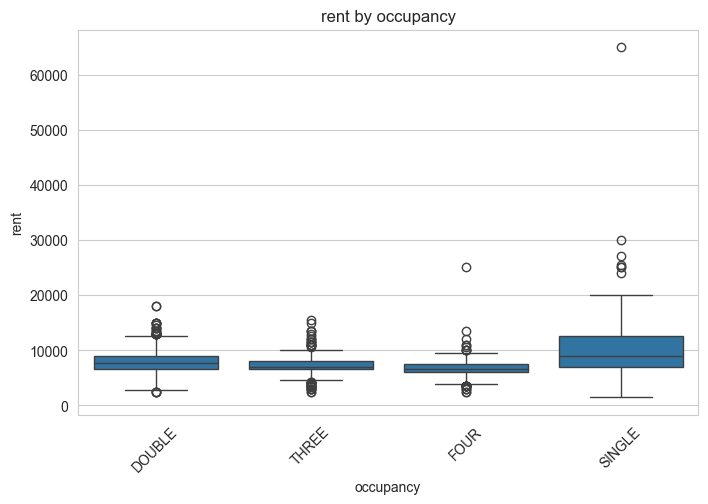

,count,mean,median
occupancy,,,
SINGLE,187,10545.187166,9000.0
DOUBLE,387,8029.819121,7700.0
THREE,459,7158.143791,7000.0
FOUR,403,6568.992556,6500.0


In [12]:
box_analysis(
    df,
    "occupancy",
    "rent"
)

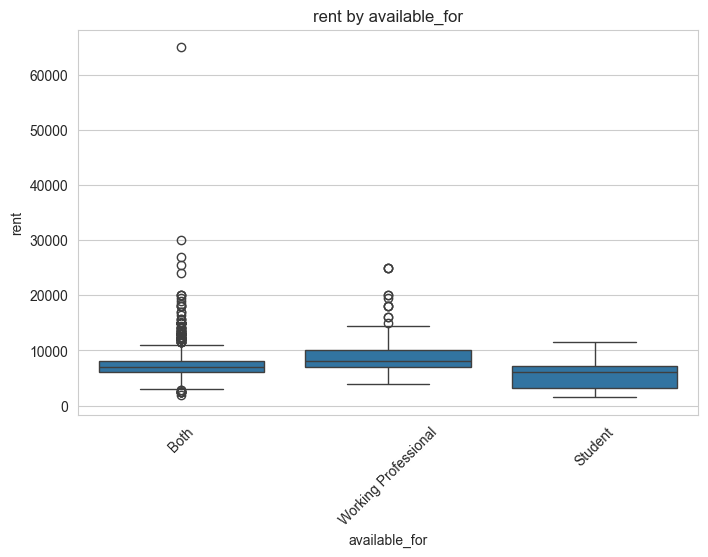

,count,mean,median
available_for,,,
Working Professional,121,9311.570248,8000.0
Both,1307,7528.448355,7000.0
Student,8,5750.000000,6000.0


In [13]:
box_analysis(
    df,
    "available_for",
    "rent"
)

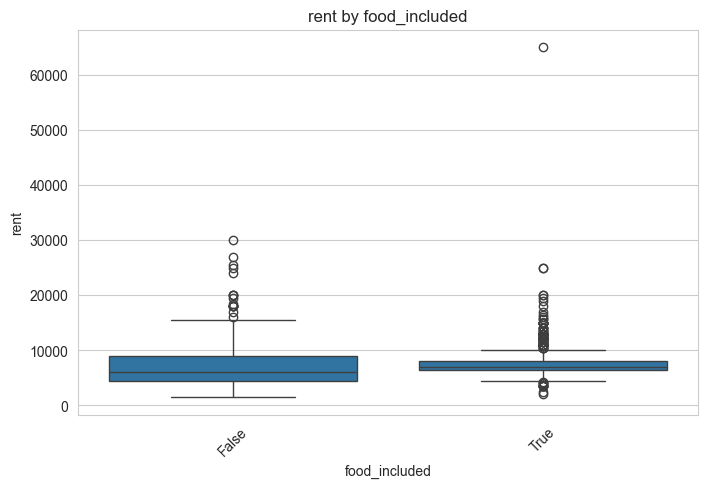

,count,mean,median
food_included,,,
True,1104,7762.635870,7000.0
False,332,7356.722892,6000.0


In [14]:
box_analysis(
    df,
    "food_included",
    "rent"
)

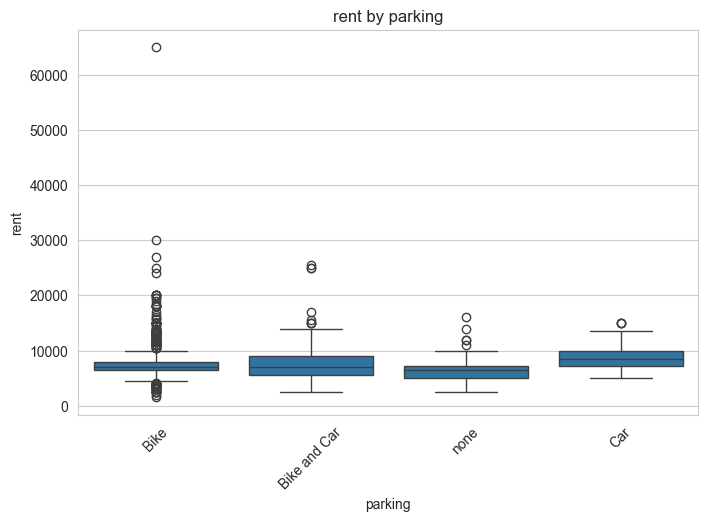

,count,mean,median
parking,,,
Car,31,9103.225806,8500.0
Bike and Car,137,7908.029197,7000.0
Bike,1156,7718.711073,7000.0
none,112,6463.857143,6500.0


In [15]:
box_analysis(
    df,
    "parking",
    "rent"
)

occupancy     DOUBLE   FOUR  SINGLE  THREE
parking                                   
Bike           0.266  0.285   0.122  0.327
Bike and Car   0.277  0.263   0.153  0.307
Car            0.323  0.161   0.194  0.323
none           0.277  0.295   0.170  0.259


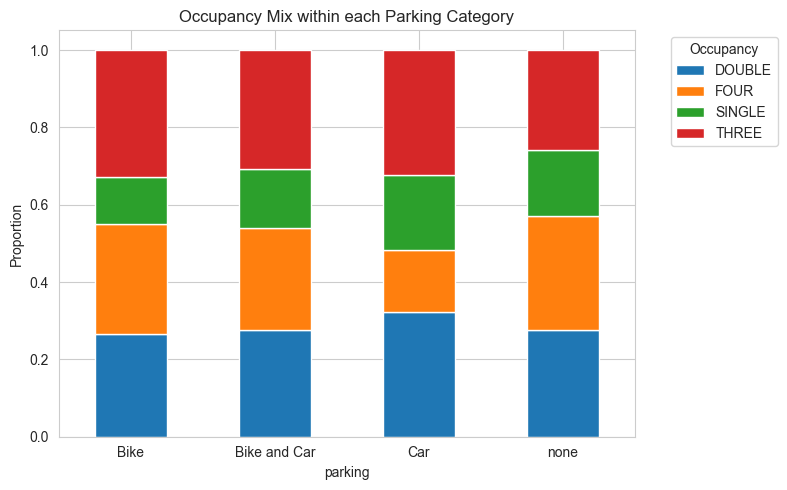

In [26]:
#  Parking x Occupancy confound check resolves the "Bike and Car" anomaly from 4.2

parking_occ = (
    df.groupby('parking')['occupancy']
    .value_counts(normalize=True)
    .unstack()
    .round(3)
)

print(parking_occ)

parking_occ.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Occupancy Mix within each Parking Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Occupancy', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

locality      Adambakkam  Alandur  Arcot Road-Kodambakkam  Ashok Nagar  \
parking                                                                  
Bike               0.010    0.014                   0.007        0.004   
Bike and Car         NaN      NaN                     NaN          NaN   
Car                  NaN      NaN                     NaN          NaN   
none               0.045    0.027                   0.009          NaN   

locality      Balaji Nagar  East Coast Road-Kottivakkam  \
parking                                                   
Bike                 0.005                        0.002   
Bike and Car         0.022                          NaN   
Car                  0.032                          NaN   
none                   NaN                          NaN   

locality      East Coast Road-Thiruvanmiyur  East Tambaram  GST Road-Tambaram  \
parking                                                                         
Bike                                  

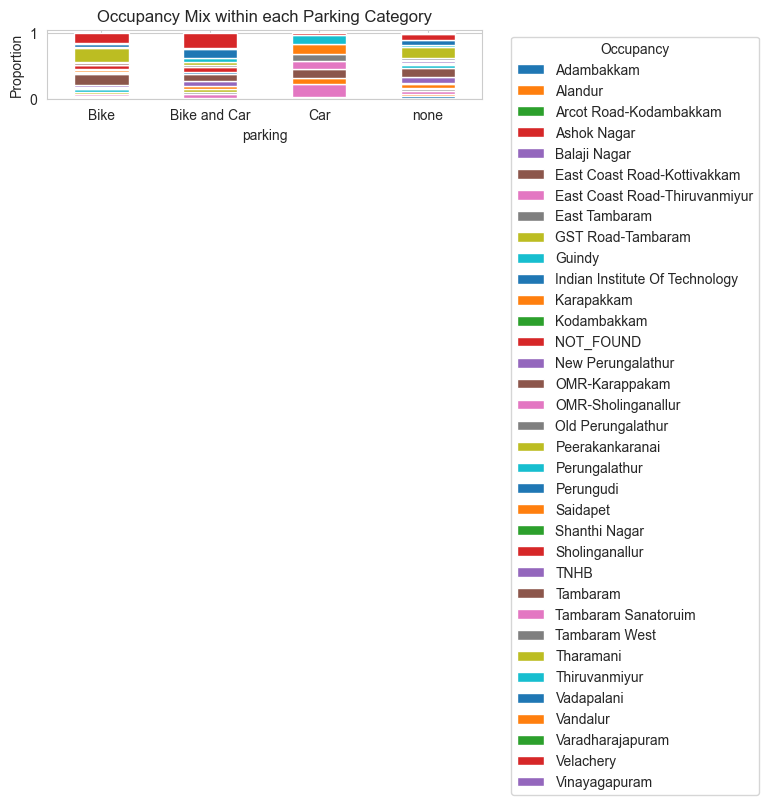

In [ ]:
  # Parking x Occupancy confound check resolves the "Bike and Car" anomaly from 4.2

parking_occ = (
    df.groupby('parking')['locality']
    .value_counts(normalize=True)
    .unstack()
    .round(3)
)

print(parking_occ)

parking_occ.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Occupancy Mix within each Parking Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Occupancy', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [28]:
#  Does locality explain the parking anomaly? (weighted comparison, not eyeballing)

locality_means = df.groupby('locality')['rent'].mean()

parking_locality_mix = (
    df.groupby('parking')['locality']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# "If locality were the only driver" — expected rent per parking category
expected_rent = (parking_locality_mix * locality_means).sum(axis=1)

actual_rent = df.groupby('parking')['rent'].mean()

comparison = pd.DataFrame({
    'expected_from_locality_mix': expected_rent.round(0),
    'actual_mean_rent': actual_rent.round(0)
})
comparison['residual'] = comparison['actual_mean_rent'] - comparison['expected_from_locality_mix']

print(comparison)

              expected_from_locality_mix  actual_mean_rent  residual
parking                                                             
Bike                              7658.0            7719.0      61.0
Bike and Car                      7740.0            7908.0     168.0
Car                               8300.0            9103.0     803.0
none                              7517.0            6464.0   -1053.0


## Top 15 Localities

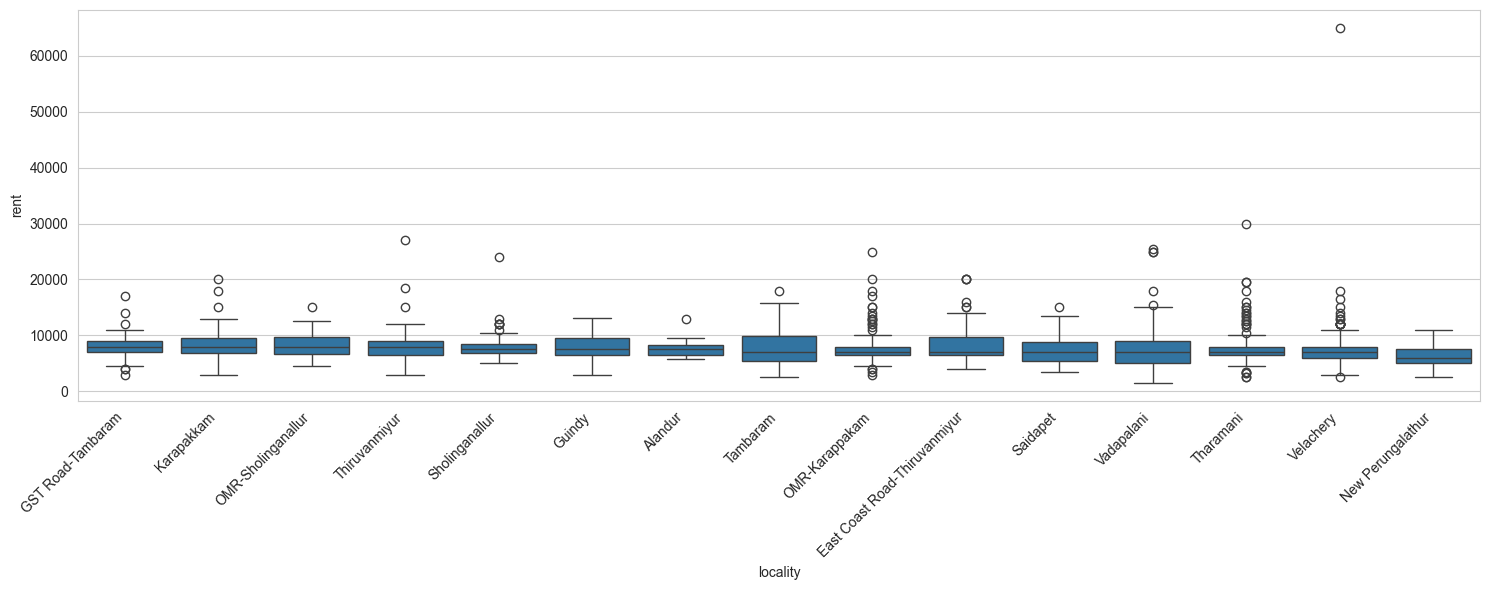

,Count,Mean,Median
locality,,,
Thiruvanmiyur,33,8948.484848,8000.0
Karapakkam,32,8903.125000,8000.0
East Coast Road-Thiruvanmiyur,51,8754.901961,7000.0
OMR-Sholinganallur,27,8288.888889,8000.0
GST Road-Tambaram,38,8131.578947,8000.0
Tambaram,46,8102.173913,7000.0
Sholinganallur,82,8064.390244,7500.0
Vadapalani,83,7969.879518,7000.0
Guindy,47,7844.680851,7500.0


In [19]:
top_localities = (
    df["locality"]
    .value_counts()
    .head(15)
    .index
)

temp = df[
    df["locality"].isin(top_localities)
]
order = (
    temp.groupby("locality")["rent"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(15,6))
sns.boxplot(
    data=temp,
    x="locality",
    y="rent",
    order=order
)

plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

display(temp.groupby("locality")["rent"].agg(Count="count",Mean="mean",Median="median").sort_values("Mean",ascending=False))

## 4.4  Confounding Checks

occupancy,DOUBLE,FOUR,SINGLE,THREE
parking,,,,
Bike,0.266436,0.284602,0.121972,0.326990
Bike and Car,0.277372,0.262774,0.153285,0.306569
Car,0.322581,0.161290,0.193548,0.322581
none,0.276786,0.294643,0.169643,0.258929


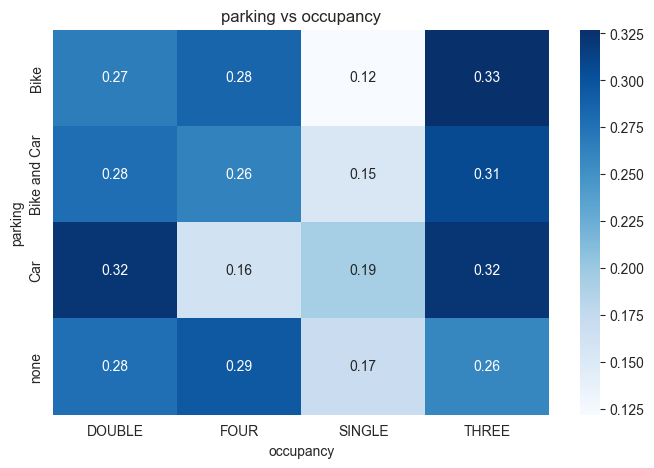

In [20]:
crosstab_analysis(
    df,
    "parking",
    "occupancy"
)

available_for,Both,Student,Working Professional
gender,,,
BOTH,0.857143,0.000000,0.142857
FEMALE,0.909357,0.001462,0.089181
MALE,0.913529,0.009763,0.076709


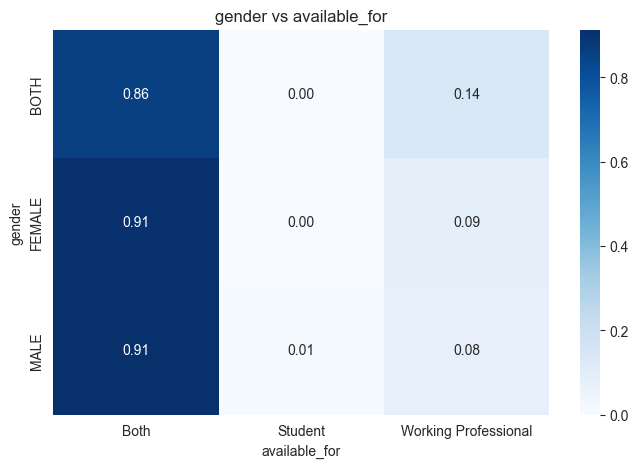

In [21]:
crosstab_analysis(
    df,
    "gender",
    "available_for"
)

In [22]:
top = df["locality"].value_counts().head(10).index

temp = df[df["locality"].isin(top)]

pd.crosstab(
    temp["locality"],
    temp["occupancy"],
    normalize="index"
)

occupancy,DOUBLE,FOUR,SINGLE,THREE
locality,,,,
East Coast Road-Thiruvanmiyur,0.294118,0.215686,0.215686,0.274510
Guindy,0.234043,0.404255,0.085106,0.276596
New Perungalathur,0.262295,0.327869,0.114754,0.295082
OMR-Karappakam,0.278027,0.269058,0.089686,0.363229
Saidapet,0.302326,0.279070,0.139535,0.279070
Sholinganallur,0.219512,0.280488,0.134146,0.365854
Tambaram,0.304348,0.239130,0.195652,0.260870
Tharamani,0.272388,0.287313,0.085821,0.354478
Vadapalani,0.265060,0.313253,0.168675,0.253012


## 4.5Interaction Analysis

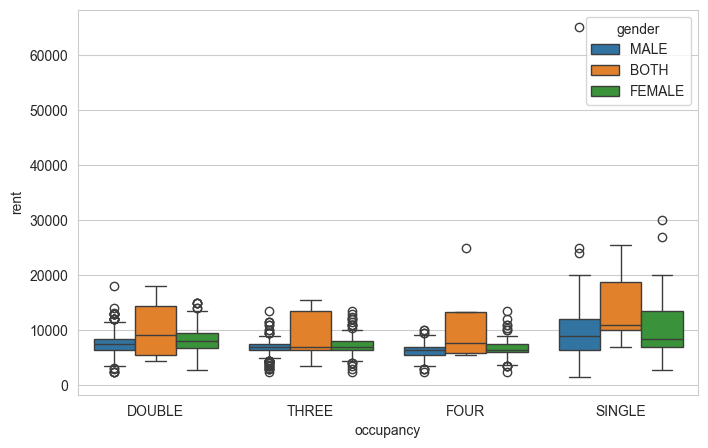

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="gender"
)

plt.show()

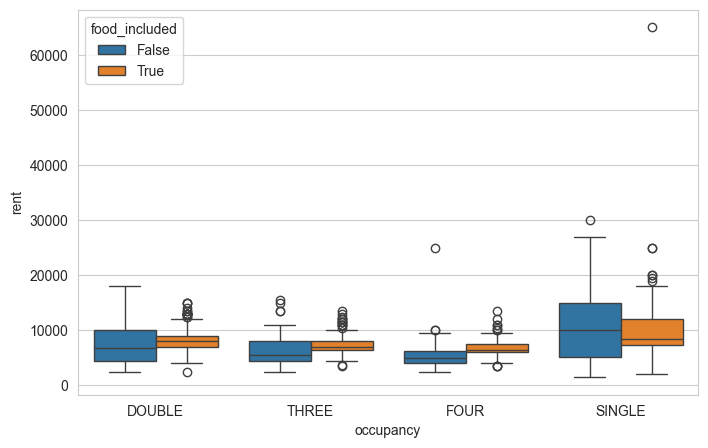

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="food_included"

)

plt.show()

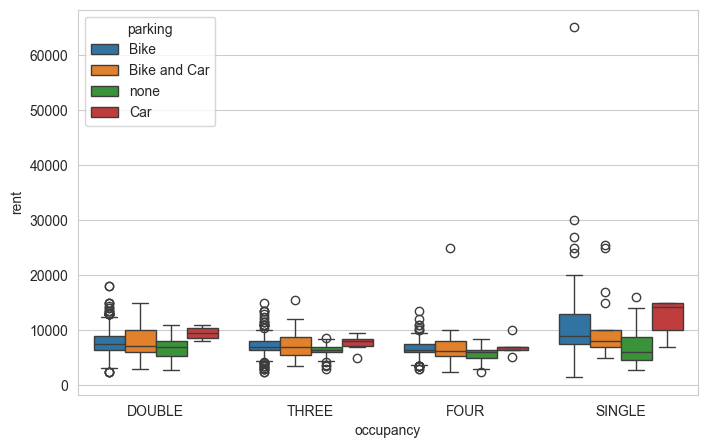

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="occupancy",
    y="rent",
    hue="parking"
)

plt.show()

# PHASE 4 — Bivariate Analysis

## Summary Notebook

**Goal:** Study the relationship between two variables, especially how each feature relates to the target variable `rent`.

The Phase 4 workflow covers:
- Numerical vs `rent`
- Correlation matrix
- Categorical features vs `rent`
- Confounding checks
- Interaction analysis
- Decisions for later feature engineering/modeling


## 1. Numerical Features vs Rent

| Feature | Pearson Correlation | Interpretation |
|---|---:|---|
| Deposit | **0.44** | Moderate positive relationship |
| Transit Score | -0.03 | Negligible linear relationship |
| Lifestyle Score | 0.02 | Negligible linear relationship |
| Latitude | 0.02 | Negligible linear relationship |
| Longitude | 0.12 | Weak positive relationship |

### Main finding
**Deposit is the strongest numerical predictor of rent.** Higher-rent PGs generally require larger deposits, although substantial spread remains at similar deposit values.

### Decision
Retain all numerical features. Weak Pearson correlation alone is not sufficient reason to remove transit or lifestyle scores because they may still contribute through nonlinear relationships.


## 2. Correlation Matrix

The numerical correlation matrix is used to examine relationships between numerical variables and to check for possible multicollinearity.

### Findings
- Deposit remains the strongest numerical feature associated with rent.
- Transit score and latitude have a moderate positive relationship (**r ≈ 0.52**).
- Transit score and lifestyle score have a mild positive relationship.
- No pair of numerical variables exhibits severe multicollinearity.

### Decision
Retain all numerical features, while noting the moderate redundancy between transit score and latitude if linear models are used later.


## 3. Categorical Features vs Rent

Categorical variables are compared with rent using boxplots and group-level count/mean/median summaries.


### Occupancy

| Occupancy | Mean Rent |
|---|---:|
| Single | ₹10,627 |
| Double | ₹8,143 |
| Three | ₹7,277 |
| Four | ₹6,638 |

Average rent decreases consistently as room sharing increases.

**Decision:** Occupancy is the strongest categorical predictor. Keep it and preserve its natural ordering during encoding.


### Locality

Top localities show meaningful differences in rent. Among high-volume localities, average rent differs by almost ₹2,800 between the highest and lowest priced areas.

**Decision:** Retain `locality` and proceed with the planned smoothed target encoding because Phase 3 identified a long-tail distribution.


### Available For

Working Professional listings exhibit the highest average rent, but nearly 89% of listings belong to the `Both/Anyone` category.

**Decision:** Retain the feature and monitor its usefulness during modeling despite the strong class imbalance.


### Food Included

Food-inclusive PGs charge approximately ₹400 more on average.

**Decision:** Retain `food_included` as a minor predictive feature.


### Parking

Raw averages suggest:

`Car > Bike > Bike & Car`

However, the apparent parking effect requires confounding analysis before drawing conclusions.


## 4. Confounding Analysis

A confounder can make a feature appear more strongly related to rent because another variable differs between its groups.


### Parking × Occupancy

The apparent parking premium is partly explained by occupancy. Car-parking listings contain a much larger proportion of Single-occupancy rooms, and Single rooms naturally command higher rents.

**Decision:** Retain parking as a separate feature. Do not collapse it into a binary variable.


### Gender × Available For

Mixed-gender (`BOTH`) PGs contain a much higher proportion of Working Professional listings.

Therefore, the higher average rent observed for `BOTH`-gender PGs is partially explained by the Working Professional composition rather than gender alone.

**Decision:** Interpret the gender effect cautiously and retain both features.


### Locality × Occupancy

Occupancy distributions vary only moderately across major localities. No locality exhibits an extreme occupancy imbalance.

**Decision:** No preprocessing action is required.


## 5. Interaction Analysis

The notebook examines:
- Occupancy × Gender
- Occupancy × Food Included
- Occupancy × Parking

### Main observation
The overall occupancy trend remains consistent across the interaction plots.

Single-sharing rooms consistently command the highest rents regardless of gender, food availability or parking category.

No interaction shows a complete reversal of the occupancy–rent relationship.


# 6. Phase 4 Summary

## Strong Predictors
- Occupancy
- Deposit
- Locality

## Moderate Predictors
- Available For
- Parking
- Food Included

## Weak Linear Predictors
- Transit Score
- Lifestyle Score
- Latitude
- Longitude


## 7. Important Findings

1. **Occupancy** is the strongest categorical driver of rent.
2. **Deposit** is the strongest numerical predictor.
3. **Locality** contributes meaningful pricing information despite its long-tail distribution.
4. Parking effects are partly explained by occupancy.
5. Mixed-gender PGs appear more expensive largely because they contain more Working Professional listings.
6. No severe multicollinearity was detected.
7. Feature selection should be delayed until model-based evaluation.


## 8. Phase 4 Decisions

| # | Decision | Status |
|---|---|---|
| 1 | Retain all numerical features | ✅ |
| 2 | Keep occupancy as an ordered categorical feature | ✅ |
| 3 | Retain locality for smoothed target encoding | ✅ |
| 4 | Keep parking as four categories | ✅ |
| 5 | Retain available_for despite class imbalance | ✅ |
| 6 | Treat transit score and latitude as moderately correlated during modeling | ✅ |
| 7 | Delay feature selection until model-based evaluation | ✅ |


## 9. Phase 4 in One Sentence

**Bivariate analysis moves from asking “What does each feature look like?” to “How is each feature related to rent, and could another variable be explaining that relationship?”**

### Next
**Phase 5 — Multivariate Analysis:** study variables together, interaction effects, feature importance and which variables remain useful when considered simultaneously.
